### Week 9
### Data wrangling and analysis
##### Yiscah Mark

#### loading the proper libraries for the dataframes, and visualizations.

In [1]:
# `pandas` for data loading/transformations
import pandas as pd

# `seaborn` for visualization
import seaborn as sns

# `matplotlib` for detailed visualization support
import matplotlib.pyplot as plt
%matplotlib notebook

#### I first started the entire assignment in jupyter notebooks. Since the dataset was very large, it kept crashing. I moved over to google colab. Here I upload the data through the import function in colab, and print the first few rows to verify and view the data. The fact that it took over 10 minutes for the dataset to load shows how large the dataset is.

In [3]:
from google.colab import files
import pandas as pd

# This will open a file picker
uploaded = files.upload()

# The file name is stored as a key in the 'uploaded' dictionary
file_name = list(uploaded.keys())[0]

# Load the data
ppp_data = pd.read_csv(file_name)

# Verify
ppp_data.head()

Saving public_150k_plus_borrower_fingerprint_a.csv to public_150k_plus_borrower_fingerprint_a.csv


,LoanNumber,DateApproved,SBAOfficeCode,ProcessingMethod,BorrowerName,BorrowerNameFingerprint,BorrowerAddress,BorrowerCity,BorrowerState,BorrowerZip,...,HEALTH_CARE_PROCEED,DEBT_INTEREST_PROCEED,BusinessType,OriginatingLenderLocationID,OriginatingLender,OriginatingLenderCity,OriginatingLenderState,Gender,Veteran,NonProfit
0,9547507704,05/01/2020,464,PPP,"SUMTER COATINGS, INC.",coatings inc sumter sumter,2410 Highway 15 South,Sumter,NaN,29150-9662,...,NaN,NaN,Corporation,19248,Synovus Bank,COLUMBUS,GA,Unanswered,Unanswered,NaN
1,9777677704,05/01/2020,464,PPP,"PLEASANT PLACES, INC.",inc places pleasant charleston north,7684 Southrail Road,North Charleston,NaN,29420-9000,...,NaN,NaN,Sole Proprietorship,19248,Synovus Bank,COLUMBUS,GA,Male Owned,Non-Veteran,NaN
2,5791407702,05/01/2020,1013,PPP,BOYER CHILDREN'S CLINIC,boyer childrens clinic seattle,1850 BOYER AVE E,SEATTLE,NaN,98112-2922,...,NaN,NaN,Non-Profit Organization,9551,"Bank of America, National Association",CHARLOTTE,NC,Unanswered,Unanswered,Y
3,6223567700,05/01/2020,920,PPP,KIRTLEY CONSTRUCTION INC,construction inc kirtley bernardino san,1661 MARTIN RANCH RD,SAN BERNARDINO,NaN,92407-1740,...,NaN,NaN,Corporation,9551,"Bank of America, National Association",CHARLOTTE,NC,Unanswered,Unanswered,NaN
4,9662437702,05/01/2020,101,PPP,AERO BOX LLC,aero box llc a n,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,57328,The Huntington National Bank,COLUMBUS,OH,Unanswered,Unanswered,NaN


#### The main way to find the amount of people who are taking a loan for the second time is by using the dates as a clue. Therefore, the first step is to convert and create datetime values using the .to_datetime function.

In [4]:
# convert the `DateApproved` column to an actual datetime data type (so we can order the entrees)
ppp_data['DateApproved'] = pd.to_datetime(ppp_data['DateApproved'])

# create a variable to hold the second-round start date. Only loans after this date have the possibility of being second rounds.
second_round_start = pd.to_datetime('2021-01-13')

# treat today's date to use as the "upper" limit on possible second-round loans (no loans after today are possible to be second round loans)
todays_date = pd.to_datetime('today')

# use 1/1/2020 as a "lower" limit, since it's before the PPP launched ( there are no loans before this date)
program_start = pd.to_datetime('2020-01-01')

#### In the following cell, all the entries are binned based on the value in the date columns. The first bin includes all the dates starting from 2020-01-01 to the cutoff date (2021-01-13) and the other is from the cutoff date untill today. Next we use the insert function to create a new column called "Loan Round" and place the values for whatever round the loan is. The two options are first_round, and Maybe_second. because anything before the cutoff date has to be the first round, anything after can be the first or second.

In [5]:
# pass our boundaries and category labels to the pandas `cut()` function
loan_round = pd.cut(ppp_data.DateApproved,
 bins=[program_start,second_round_start, todays_date],
 labels=['first_round', 'maybe_second'])

# insert the new column at the position we specify
ppp_data.insert(2,'Loan Round',loan_round)

#### In the following cell I get a lot of summary statistics about my data. A big point is to count out how many times each unique borrower borrowed money. We also extract information such as the mean, standard deviation, and percentiles, also the minimum and maximum of loans per unique individual.

In [6]:
# this "pivot table" will return a Series showing the number
# of times a particular 'BorrowerNameFingerprint' appears in the dataset
loan_count = ppp_data.pivot_table(index=['BorrowerNameFingerprint'],
 aggfunc='size')

# convert our Series to a DataFrame and give it a name
loan_count_df = loan_count.to_frame('Loan Count')

# use the `describe()` method to print out summary statistics
print("Description of duplicate borrower table:")
print(loan_count_df.describe())
# start by sorting our DataFrame of loan counts from greatest to least
sorted_loan_counts = loan_count_df.sort_values(by=['Loan Count'],
 ascending=False)



Description of duplicate borrower table:
          Loan Count
count  694279.000000
mean        1.104022
std         0.306489
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        12.000000


#### In the following cell a new data frame is created that only includes those borrowers that have more than two loans. First we count those businesses that got more than two loans, and then we count those that seem to have gotten exactly two loans.

In [7]:
# create a new DataFrame with *only* those that have more than two loans
more_than_two = sorted_loan_counts[sorted_loan_counts['Loan Count'] > 2]

# print one instance of each business name that appears in `more_than_two`
print("Businesses that seem to have gotten more than 2 loans:")
print(more_than_two.shape)
print("Number of businesses that appear to have gotten precisely 2 loans:")
precisely_two = sorted_loan_counts[sorted_loan_counts['Loan Count'] == 2]
print(precisely_two.shape)

Businesses that seem to have gotten more than 2 loans:
(58, 1)
Number of businesses that appear to have gotten precisely 2 loans:
(72060, 1)


#### Previously I used a cutoff date to guess what loans were second time loans. Now, I will use a more reliable method and see if the two align at all with each other. I will see wich have PPS in the processing method column. PPS stands for "Paycheck Protection Program Second Draw". this seems like a better way to check. I will then print the shape to see how many values there are.

In [8]:
# use `ProcessingMethod` value to identify second-round loans
pps_loans = ppp_data[ppp_data['ProcessingMethod'] == 'PPS']

# print out the `shape` of this DataFrame to see how many businesses we have
print("Number of loans labeled as second round:")
print(pps_loans.shape)

Number of loans labeled as second round:
(103949, 52)


#### In this cell I check my two ways of getting my information against each other. I count all those loans of exactly 2 million dollars that fall out in the second bin dates against those loans that are for exactly 2 million dollars that have PPS.

In [9]:
# how many loans in our derived data frame were approved for precisely $2M
# during the (possibly) second-round timeframe?
# merge our `loan_count_df` back to keep track of businesses
# we labeled as having precisely two loans
ppp_data_w_lc = pd.merge(ppp_data, loan_count_df,
 on=['BorrowerNameFingerprint'], how='left')

# now get *all* the records of business names we associated with two loans
matched_two_loans = ppp_data_w_lc[(ppp_data_w_lc['Loan Count'] == 2)]

# select those loans our `maybe_second` loans that have a value of $2M
maybe_round2_2M = matched_two_loans[
 (matched_two_loans['CurrentApprovalAmount'] == 2000000.00) &
 (matched_two_loans['Loan Round'] == 'maybe_second')]
print("Derived $2M second-round loans:")
print(maybe_round2_2M.shape)

# select those loans that we *know* are second round and have a value of $2M
pps_got_2M = pps_loans[pps_loans['CurrentApprovalAmount'] == 2000000.00]
print("Actual $2M second-round loans:")
print(pps_got_2M.shape)

Derived $2M second-round loans:
(1175, 53)
Actual $2M second-round loans:
(1459, 52)


#### Here I join together the original dataset with the new dataframe that only has the second time loans. We create a dataframe that inludes also the first time loan information only about those businesses that recieved second loans.

In [13]:
import numpy as np
# isolate the fingerprints of businesses that got $2M second-round loans approved
biz_names = pd.unique(pps_got_2M['BorrowerNameFingerprint'])

# convert that list to a DataFrame
biz_names_df = pd.DataFrame(biz_names, columns=['BorrowerNameFingerprint'])

# create a new array of the same length as our biz_names_df and fill with
# a flag value
fill_column = np.full((len(biz_names),1), '2Mil2ndRnd')
biz_names_df['GotSecond'] = fill_column

# now merge this new, two-column DataFrame back onto our full_data list,
# so that we (hopefully) find their first-round loans as well
second_round_max = pd.merge(ppp_data_w_lc, biz_names_df,
 on='BorrowerNameFingerprint')

#### Validating that it worked by checking the shape of the new dataframe.

In [14]:
# now all the loans that share fingerprints with the ones that got the max
# amount in the second round should have the flag value '2Mil2ndRnd' in the
# 'GotSecond' column
second_max_all_loans = second_round_max[
 second_round_max['GotSecond'] == '2Mil2ndRnd']

# we expect this to be twice the number of businesses that received $2M
# second-round loans
print('Total # of loans approved for most orgs that got $2M for second round:')
print(second_max_all_loans.shape)

Total # of loans approved for most orgs that got $2M for second round:
(2634, 54)


#### In this cell we calculate the sum of all the money borrowed by those businesses that got a second loan. This means that the number will be 2 million times however many businesses recieved second loans plus the sum of all their first loans. It is a very high number.

In [15]:
# how much money were these businesses approved to get from the PPP, total?
total_funds = second_max_all_loans['CurrentApprovalAmount'].sum()
print("Total funds approved for identified orgs that could have " + \
 "second-round max:")
print(total_funds)

Total funds approved for identified orgs that could have second-round max:
6250357574.440001


#### In this last cell we can view the data visualy based on the two methods of extracting those with second round loans. We see that using either method got us very similar results which leads to the assumption that we are probably correct.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

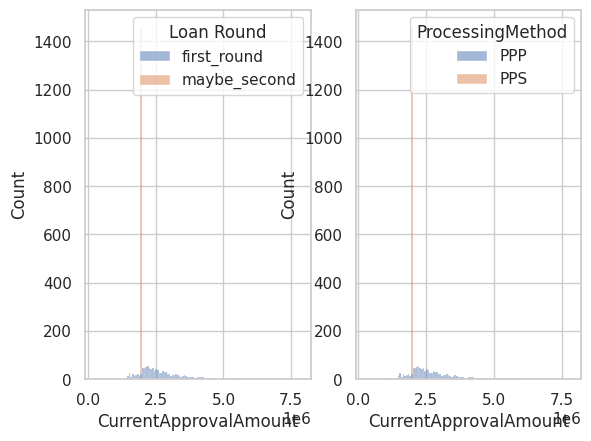

In [18]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# plot our date-based `Loan Round`-labeled data next to records
# separated by `ProcessingMethod`. Do we get the same results?
# set the seaborn theme
sns.set_theme(style="whitegrid")

# use `matplotlib` `subplots()` to plot charts next to each other
# use `tuples` to access the different subplots later
fig, ((row1col1, row1col2)) = plt.subplots(nrows=1, ncols=2)

# plot the histogram of our date-based analysis
date_based = sns.histplot(data=second_max_all_loans, x='CurrentApprovalAmount',
 hue='Loan Round', ax=row1col1)

# plot the histogram of our data-based analysis
data_based = sns.histplot(data=second_max_all_loans, x='CurrentApprovalAmount',
 hue='ProcessingMethod', ax=row1col2)

# show the plot!
plt.show()

#### This assignment was a deep dive into analysis. Dealing with data isn't always as straight foreward as cleaning it up. Even in cleaning the data, there isn't a checklist to go through. Every dataset has it's unique situation and different methods to clean it best.
#### In analysis, there is especially no pattern. We use different logic each time to achieve the wanted results. One has to look at the data with a logical curious eye, and has to have reasonable knowledge in the feild.

#### In this specific dataset the author noticed in a chart of the loans that around very neat intervals of money the loan counts were spiking up. A pretty simple conclusion was that people generaly round loans for simplicity.

#### An even bigger eye opener was the huge spike at the 2 million dollar marker. The first point was to try and figure out why using information about these loans. The author found that the maximum second-time loan was $2,000,000. This is very telling as to why it is such a common number. Now the author created a notebook with two different ways of finding out who weas borrowing 2 million dollars as a second time loan.

#### The first way to find out was to use the dates. Apparently, it was impossible to get a second loan before 2021-01-13. The data was split into two bins based on the date column. Those before the cutoff were labeled first round and those after the cutoff are "possible second".

#### Another way to identify second time loans was to check the processing method column. Those with the pps method are second round loans. This way is more straightforward and likely more accurate. We then compare the results of the two million dollar loans in each of these two categories to see if we got similar results.
